In [4]:
%load_ext aiida
%aiida

Loaded AiiDA DB environment - profile name: bit.

In [16]:
from icet.tools.structure_generation import generate_sqs, generate_sqs_from_supercells
from icet import ClusterSpace
from aiida_grouppathx import GroupPathX
from aiida import orm

from icet.input_output.logging_tools import set_log_config
from ase.build.supercells import find_optimal_cell_shape, make_supercell
import numpy as np
from ase.visualize import view

In [6]:
from aiida_grouppathx import GroupPathX
basepath = GroupPathX('hc-rocksalt')

In [7]:
template = basepath['structures']['pbse_init'].get_node().get_ase()

In [8]:
cs = ClusterSpace(template, [12, 8], [['Pb'], ['Se', 'Te']])
print(cs.primitive_structure.cell.cellpar())
print(cs)

[ 4.41574568  4.41574568  4.41574567 59.99999975 60.00000002 59.99999995]
====================================== Cluster Space ======================================
 space group                            : Fm-3m (225)
 chemical species                       : ['Se', 'Te'] (sublattice A)
 cutoffs                                : 12.0000 8.0000
 total number of parameters             : 16
 number of parameters by order          : 0= 1  1= 1  2= 7  3= 7
 fractional_position_tolerance          : 2e-06
 position_tolerance                     : 1e-05
 symprec                                : 1e-05
-------------------------------------------------------------------------------------------
index | order |  radius  | multiplicity | orbit_index | multicomponent_vector | sublattices
-------------------------------------------------------------------------------------------
   0  |   0   |   0.0000 |        1     |      -1     |           .           |      .     
   1  |   1   |   0.0000 |     

Make 64-atom supercell

In [17]:
supercell = make_supercell(cs.primitive_structure, np.array([[-2,  2,  2],
       [ 2, -2,  2],
       [ 2,  2, -2]]))

In [18]:
import logging

In [21]:
set_log_config(level=logging.INFO)
results = {}
for conc in [0.25, 0.5, 0.75]:
    sqs_rocksalt = generate_sqs_from_supercells(cs, [supercell], {'Se': conc, 'Te': 1-conc}, n_steps=10000)
    results[conc] = sqs_rocksalt

icet.target_cluster_vector_annealing: INFO  Initializing target cluster vector annealing with 1 supercells
icet.target_cluster_vector_annealing: INFO  MC step 0/10000 (0 accepted trials, temperature 5.000), best score: 1.188
icet.target_cluster_vector_annealing: INFO  MC step 1000/10000 (606 accepted trials, temperature 1.251), best score: -3.574
icet.target_cluster_vector_annealing: INFO  MC step 2000/10000 (949 accepted trials, temperature 0.875), best score: -3.574
icet.target_cluster_vector_annealing: INFO  MC step 3000/10000 (1189 accepted trials, temperature 0.654), best score: -3.574
icet.target_cluster_vector_annealing: INFO  MC step 4000/10000 (1346 accepted trials, temperature 0.498), best score: -3.574
icet.target_cluster_vector_annealing: INFO  MC step 5000/10000 (1441 accepted trials, temperature 0.377), best score: -3.574
icet.target_cluster_vector_annealing: INFO  MC step 6000/10000 (1498 accepted trials, temperature 0.278), best score: -3.574
icet.target_cluster_vector_

## Launch band structure for SQS

In [70]:
from aiida_vasp.workchains.v2 import VaspBandUpdater, VaspRelaxUpdater,VaspHybridBandUpdater


In [84]:
def launch_hse06(node, label, lreal=False):
    """Generate process builder"""
    queue_name = 'xhhctdnormal'
    code = 'vasp-6.4.2@sugon-xh-v2'
    upd = VaspHybridBandUpdater().apply_preset(structure=node, overrides={
        'lhfcalc': True,
        'hfscreen': 0.2,
        'precfock': 'fast',
        'ispin': 1,
        'gga': None,  # PBE functional
        'magmom': None,
        'ncore': 2,
        'kpar': 8,
        'lreal': lreal, 
    },
         code=code, label=f'{node.get_formula()} {node.label}THSE06')
    upd.set_resources(num_machines=4, tot_num_mpiprocs=256)
    upd.set_options(max_wallclock_seconds=3600 * 48, queue_name=queue_name)
 
    # Only re-try twice if there is convergence problem
    upd.builder.scf.max_iterations = 2

    # Do relaxation - this is needed for getting the IBZKPT
    upd_relax = VaspRelaxUpdater(builder=upd.builder.relax)
    upd_relax.apply_preset(structure=node, overrides={
        #'metagga': 'mbj',
        'ispin': 1,
        'gga': None,
        'magmom': None,
        'ncore': 8,
    },
         code=code, label=f'{node.get_formula()} {node.label} PBE RELAX')
    upd_relax.set_resources(num_machines=1, tot_num_mpiprocs=64)
    upd_relax.set_options(max_wallclock_seconds=3600 * 12, queue_name=queue_name)
    #upd_relax.set_relax_settings(perform=False) # Not actually relaxing
    upd.set_band_settings(band_mode='bradcrack', line_density=15, kpoints_per_split=200)
    running = upd.submit()
    return running, label

In [72]:
from ase.build import sort

In [98]:
basepath['sqs_hse06_bs'].show_tree()

sqs_hse06_bs
├── pbsete_0.25 *
├── pbsete_0.5 *
├── pbsete_0.5_lreal *
└── pbsete_0.75 *



In [100]:
from aiida_vasp.utils.sumo import get_sumo_bands_plotter

<module 'matplotlib.pyplot' from '/home/bonan/miniconda3/envs/aiida/lib/python3.12/site-packages/matplotlib/pyplot.py'>

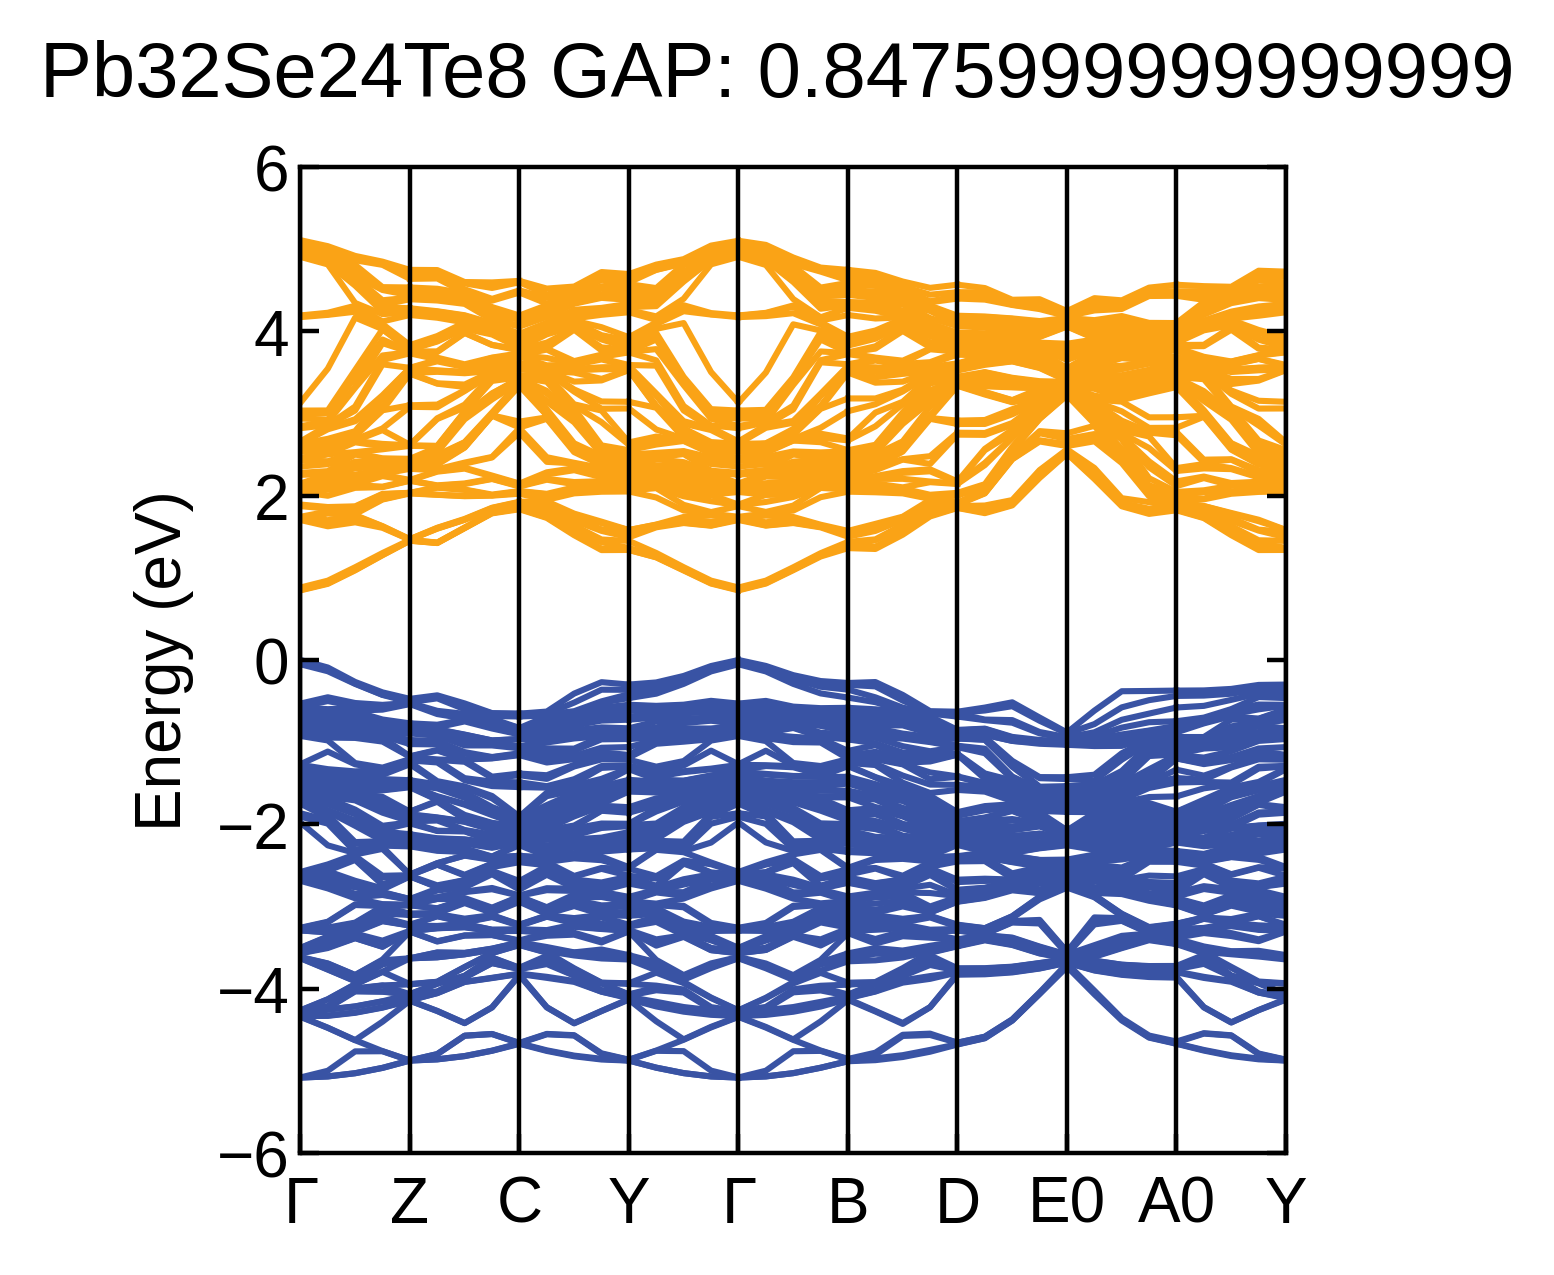

In [105]:
node = basepath['sqs_hse06_bs']['pbsete_0.25'].get_node()
plotter = get_sumo_bands_plotter(node.outputs.band_structure, structure=node.outputs.primitive_structure)
gap = plotter.bs.get_band_gap()['energy']
label = node.label.split()[0]
plotter.get_plot(title=f'{label} GAP: {gap}')

<module 'matplotlib.pyplot' from '/home/bonan/miniconda3/envs/aiida/lib/python3.12/site-packages/matplotlib/pyplot.py'>

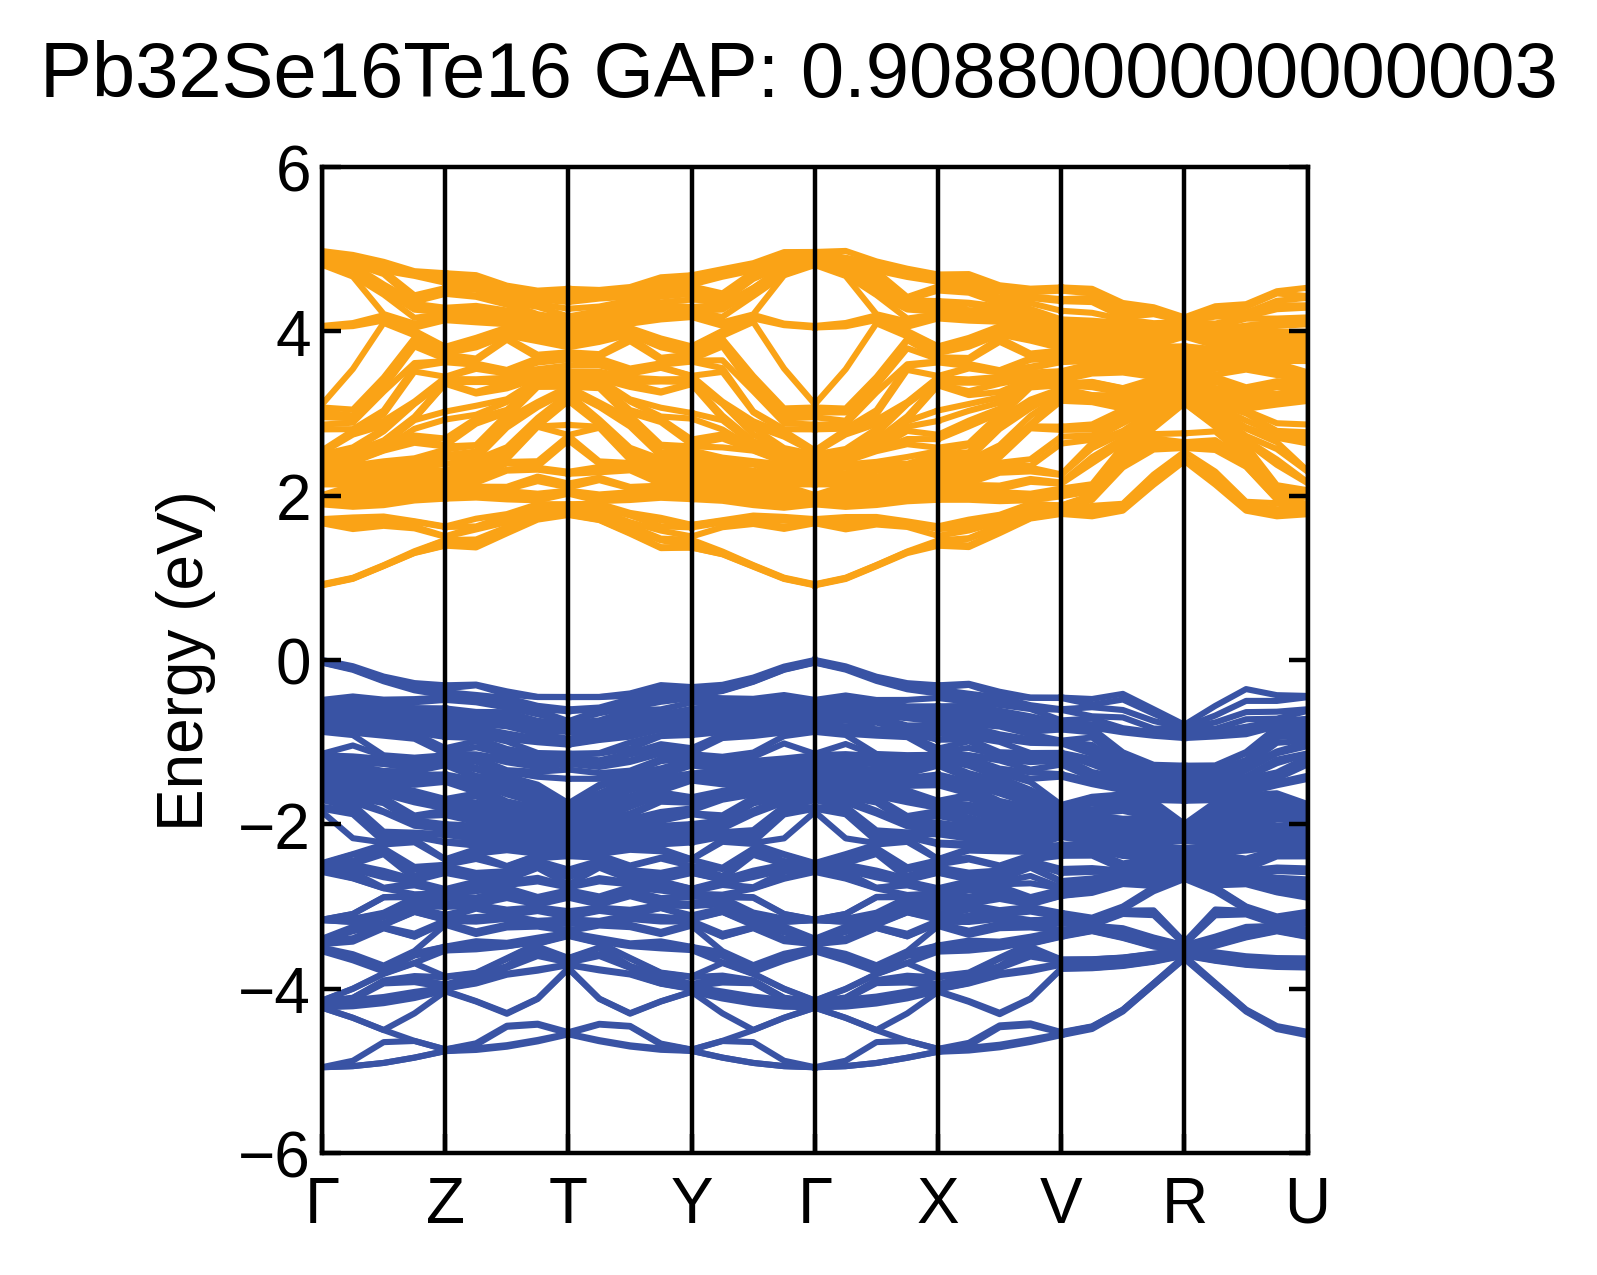

In [107]:
node = basepath['sqs_hse06_bs']['pbsete_0.5'].get_node()
plotter = get_sumo_bands_plotter(node.outputs.band_structure, structure=node.outputs.primitive_structure)
gap = plotter.bs.get_band_gap()['energy']
label = node.label.split()[0]
plotter.get_plot(title=f'{label} GAP: {gap}')

<module 'matplotlib.pyplot' from '/home/bonan/miniconda3/envs/aiida/lib/python3.12/site-packages/matplotlib/pyplot.py'>

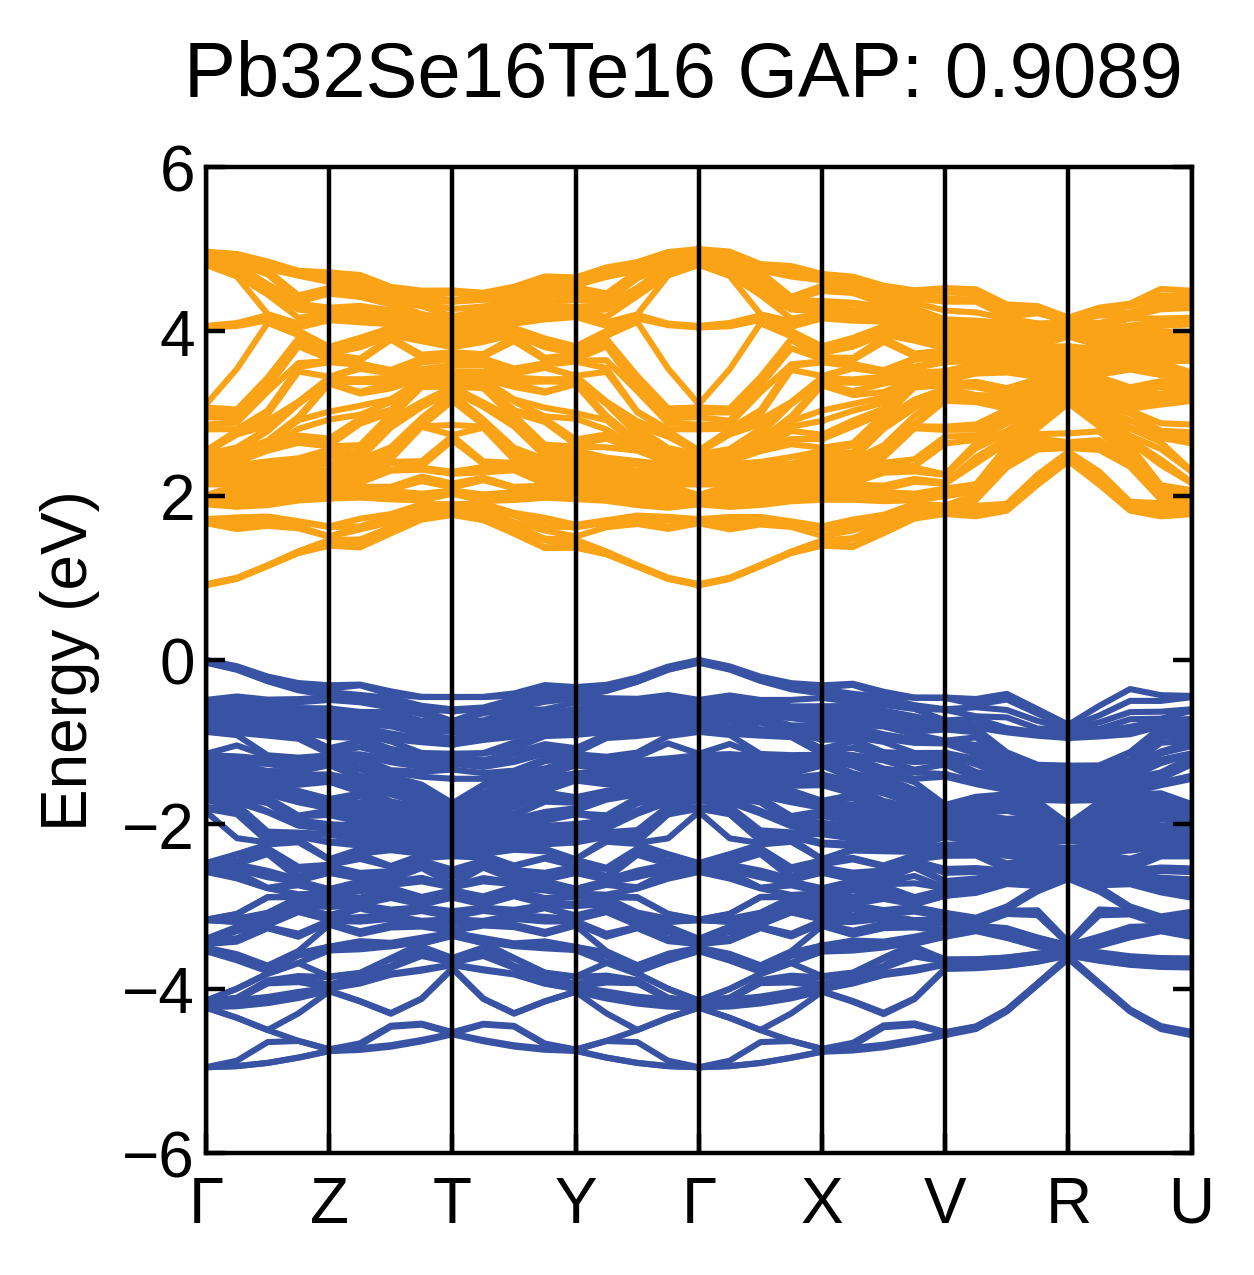

In [116]:
node = basepath['sqs_hse06_bs']['pbsete_0.5_lreal'].get_node()
plotter = get_sumo_bands_plotter(node.outputs.band_structure, structure=node.outputs.primitive_structure)
gap = plotter.bs.get_band_gap()['energy']
label = node.label.split()[0]
plotter.get_plot(title=f'{label} GAP: {gap}')

<module 'matplotlib.pyplot' from '/home/bonan/miniconda3/envs/aiida/lib/python3.12/site-packages/matplotlib/pyplot.py'>

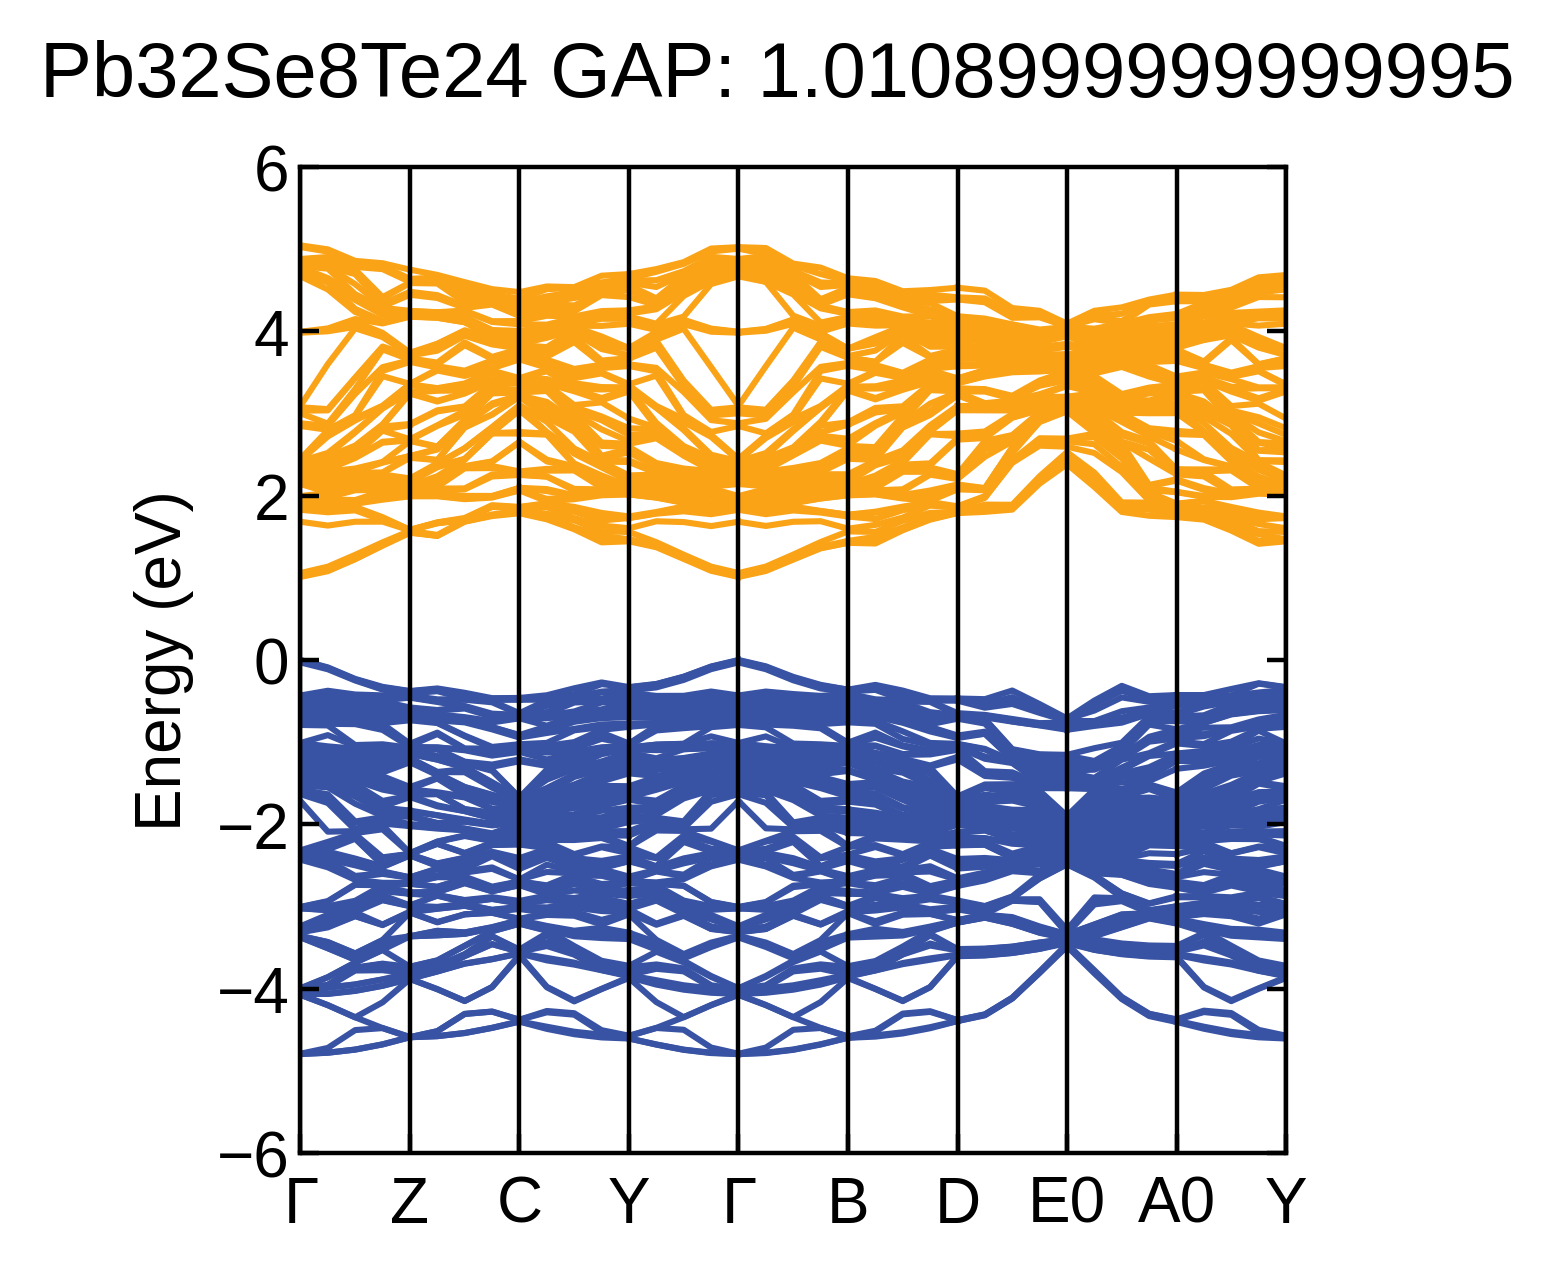

In [115]:
node = basepath['sqs_hse06_bs']['pbsete_0.75'].get_node()
plotter = get_sumo_bands_plotter(node.outputs.band_structure, structure=node.outputs.primitive_structure)
gap = plotter.bs.get_band_gap()['energy']
label = node.label.split()[0]
plotter.get_plot(title=f'{label} GAP: {gap}')

## Take a subset of the kpoints path for SOC calculation

Generate a subset of the kpoints as we are only interested in those close to the gamma point

First, check the format of the kpoints wiht labels

In [194]:
node = basepath['sqs_hse06_bs']['pbsete_0.5_lreal'].get_node()
node.called_descendants[-2].inputs.band_kpoints.base.attributes.all

{'labels': ['\\Gamma', 'Z', 'T', 'Y', '\\Gamma', 'X', 'V', 'R', 'U'],
 'array|kpoints': [33, 3],
 'label_numbers': [0, 4, 8, 12, 16, 20, 24, 28, 32]}

The subprocess launched by the original workchain
```
VaspHybridBandsWorkChain<611112> Finished [0] [6:inspect_and_combine_bands]
    ├── VaspRelaxWorkChain<611135> Finished [0] [4:finalize]
    │   ├── VaspWorkChain<611145> Finished [0] [4:results]
    │   │   └── VaspCalculation<611152> Finished [0]
    │   └── VaspWorkChain<611174> Finished [0] [4:results]
    │       └── VaspCalculation<611177> Finished [0]
    ├── kpath_from_sumo_v2<611194> Finished [0]
    ├── extract_kpoints_from_retrieved<611197> Finished [0]
    ├── VaspWorkChain<611200> Finished [0] [4:results]
    │   └── VaspCalculation<611203> Finished [0]
    ├── split_kpoints<611351> Finished [0]
    ├── VaspWorkChain<611354> Finished [0] [4:results]
    │   └── VaspCalculation<611356> Finished [0]
    └── combine_bands_data<613752> Finished [0]
```

Construct a new KpointDdata with the same format

In [195]:
# Select Y - \\Gamma - Z - Y - \\Gamma - X
labels = ['\\Gamma', 'Z', 'Y', '\\Gamma', 'X']  # High symmetry kpoints
band_kpoints = node.called_descendants[-2].inputs.band_kpoints
kpoints = band_kpoints.get_kpoints()  # The original kpoints
orig_labels = np.array(band_kpoints.base.attributes.all['labels'])  # The orignal labels
orig_labels_numbers  = np.array(band_kpoints.base.attributes.all['label_numbers'])  # The idx of the high symmetry point in the list of kpoints 
end_point_idxs = [orig_labels_numbers[np.where(orig_labels==x)[0][0]] for x in labels] # Locate the high symmetry point 
end_points = kpoints[end_point_idxs]

Now, construct the path manually. The code below does not allow breakpoint (only close loop)

In [197]:
labels = ['\\Gamma', 'Z', 'Y', '\\Gamma', 'X']
label_numbers = []
points = []
ndiv = 4
for i in range(len(end_points)-1):
    label_numbers.append(len(points))
    start = end_points[i]
    end = end_points[i +1]
    kpts = np.linspace(start, end, endpoint=False, num=ndiv)
    points.extend(list(kpts))
# Add the final end point
label_numbers.append(len(points))
new_kpoints = np.stack(points, axis=0)

# Construct the KpointsData object
new_kpoints_data = orm.KpointsData()
new_kpoints_data.set_kpoints(new_kpoints)
new_kpoints_data.set_cell_from_structure(node.outputs.primitive_structure)
new_kpoints_data.base.attributes.set('labels', labels)
new_kpoints_data.base.attributes.set('label_numbers', label_numbers)

In [186]:
# Construct the new builder
new_builder = node.get_builder_restart()

new_builder.structure = node.outputs.primitive_structure # Use the primitive structure generated as the input
new_builder.bs_kpoints = new_kpoints_data  # Assign the new kpoints data to the bs_kpoints port
new_builder.scf.code = load_code('vasp-6.4.2-ncl@sugon-xh-v2')
new_builder.relax = {}  # No need to do relax
new_builder.scf.kpoints = node.called_descendants[-2].inputs.scf_kpoints  # Reuse the SCF kpoints
new_builder.metadata.label += ' SOC'
pdict = new_builder.scf.parameters.get_dict()
pdict['incar']['lsorbit'] = True
new_builder.scf.parameters = orm.Dict(pdict)

In [188]:
from aiida.engine import submit

In [189]:
submit(new_builder)

<WorkChainNode: uuid: 25cca8be-32fc-41ea-a74e-16aaf9f14b08 (pk: 613756) (aiida.workflows:vasp.hybrid_bands)>